## Cuties Segmentation



## Task Description

You are given images of cats & dogs of different breeds. Your task is to segment creatures on them, i.e. produce a binary segmentation map for every image. Data is divided into:
- validation set containing 20 images of cats & dogs and their corresponding binary segmentation mapsж
- test set containing 1000 images of cats & dogs. You need to produce segmentation maps for these.

Due to computational constraints of LAIda, you are only allowed to use one pre-trained CLIP model to solve the task. More precisely, **RULES**:
- You cannot use any pre-trained models except the given CLIP
- You cannot use any external dataset
- You are allowed create any prompts for CLIP though.
- Except the rules above, you can do anything, including training on validation data (good luck)

Except this, you are given a list of cats & dogs breeds which are present in the data. It is not guaranteed though that every breed is present in the validation data. These are the following:

In [1]:
class_names = ['american_bulldog',
 'basset_hound',
 'keeshond',
 'British_Shorthair',
 'Sphynx',
 'pomeranian',
 'Egyptian_Mau',
 'Birman',
 'american_pit_bull_terrier',
 'japanese_chin',
 'Maine_Coon',
 'beagle',
 'Bombay',
 'wheaten_terrier',
 'shiba_inu',
 'havanese',
 'miniature_pinscher',
 'yorkshire_terrier',
 'boxer',
 'scottish_terrier',
 'newfoundland',
 'chihuahua',
 'saint_bernard',
 'Persian',
 'Bengal',
 'german_shorthaired',
 'english_cocker_spaniel',
 'leonberger',
 'Siamese',
 'Abyssinian',
 'staffordshire_bull_terrier',
 'Ragdoll',
 'pug',
 'Russian_Blue',
 'samoyed',
 'english_setter',
 'great_pyrenees']

And here's a pre-trained CLIP model that you can use to solve the task:

In [2]:
from transformers import AutoProcessor, CLIPModel, CLIPImageProcessor

device = 'cuda:0'
model_name = "openai/clip-vit-base-patch16"

processor = AutoProcessor.from_pretrained(model_name)

model = CLIPModel.from_pretrained(model_name).to(device)
model.eval()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05, eleme

## Baseline

Our baseline solution will do the following for each test image:
1. Compute CLIP embeddings of all class names
2. Resize image into size (224, 224) (typical size of images that out CLIP takes as input)
3. Compute CLIP embedding of image using CLIP image encoder
4. Compute cosine similarity between image embedding and all the text embeddings, get the class with highest similarity (i.e. do zero-shot classsification). That's how we determine what type of cat/dog is on the current image. 
5. Split image into patches of size (16, 16)
6. Run each patch as an individual image through CLIP image encoder, get its embedding
7. Get cosine similarity between embedding of each patch and embedding of class name (class name that we got from step 4). That's how we get a heatmap of a size (224//16, 224//16)
8. Interpolate this heatmap back to the size of (224, 224)
9. Get segmentation map by comparing values of the heatmap with some threshold
10. Resize the heatmap back into the original size of an image
11. Profit!!

So let's go:

In [3]:
import torch
from torch.nn import functional as F

In [4]:
classes = [' '.join(x.lower().split('_')) for x in class_names]
classes_tokenized = processor(text=classes, images=None, return_tensors="pt", padding=True).to(device)
classes_encoded = model.get_text_features(**classes_tokenized)

if hasattr(classes_encoded, 'pooler_output'):
    classes_encoded = classes_encoded.pooler_output
elif hasattr(classes_encoded, 'last_hidden_state'):
    classes_encoded = classes_encoded.last_hidden_state[:, 0, :]
else:
    raise TypeError(f"Unexpected output type: {type(classes_encoded)}")

classes_encoded = F.normalize(classes_encoded, dim=-1)

In [16]:
PATCH_SIZE = 16
CLIP_IMG_SIZE = 224
NUM_PATCHES = CLIP_IMG_SIZE // PATCH_SIZE

In [12]:
def get_clip_representation(imgs):
    
    with torch.no_grad():
        inputs = processor(text='', images=imgs, return_tensors="pt").to(device)
        outputs = model(**inputs, output_hidden_states=True)
        images_encoded = F.normalize(outputs.image_embeds, dim=-1)

    return images_encoded

In [13]:
from tqdm import tqdm
import os
from PIL import Image
import numpy as np
import torchvision.transforms as transforms

def generate_seg_masks(imgs_path, classes_encoded):

    imgs_names = []
    heatmaps = []

    for img_name in tqdm(os.listdir(imgs_path)):

        # loading image
        img = Image.open(os.path.join(imgs_path, img_name))

        # save original img width and height
        img_shapes = np.array(img).shape
        

        # get clip embedding of the whole image
        image_encoded = get_clip_representation(img)

        # determine class of the image
        chosen_class_num = (image_encoded @ classes_encoded.T).argmax(axis=1)[0]
        # get embedding of the chosen class description
        chosen_class_emb = classes_encoded[chosen_class_num]

        # resize image and split it into tiles 
        img = np.array(img.resize((CLIP_IMG_SIZE, CLIP_IMG_SIZE)))
        img_patches = [Image.fromarray(img[x:x+PATCH_SIZE,y:y+PATCH_SIZE]) for x in range(0,CLIP_IMG_SIZE,PATCH_SIZE) for y in range(0,CLIP_IMG_SIZE,PATCH_SIZE)]

        # get cosine similarities between patches embeddings and class embedding
        img_patches_embs = get_clip_representation(img_patches)
        img_patches_embs_sims = img_patches_embs @ chosen_class_emb.unsqueeze(0).T

        # form a heatmap
        heatmap = img_patches_embs_sims
        heatmap = heatmap.reshape(NUM_PATCHES, NUM_PATCHES).unsqueeze(0)
        # interpolate heatmap into size (CLIP_IMG_SIZE, CLIP_IMG_SIZE)
        heatmap = torch.nn.functional.interpolate(heatmap[:, np.newaxis],
                                            scale_factor=PATCH_SIZE,
                                            mode='bilinear').to(device)

        # threshold between FG(foreground) and BG(background) is the mean value of a heatmap
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
        mean_heatmap_value = heatmap.mean()
        # get segmentation map 
        heatmap = heatmap.ge(mean_heatmap_value).type(heatmap.type())

        # resize segmentation map back to original size
        target_transform = transforms.Compose([
            transforms.Resize((img_shapes[0], img_shapes[1]), Image.NEAREST),
        ])
        heatmap = target_transform(heatmap).data.cpu().numpy()

        # save generated heatmap of a current image
        imgs_names.append(img_name)
        heatmaps.append(heatmap[0][0])

    return imgs_names, heatmaps

In [14]:
import kagglehub

path = kagglehub.competition_download('neoai-2025-cuties-segmentation')

print("Path to competition files:", path)

Path to competition files: C:\Users\raian\.cache\kagglehub\competitions\neoai-2025-cuties-segmentation


In [15]:
val_imgs_path = path + '/cuties/val_imgs/'
val_masks_path = path + '/cuties/val_masks/'

val_img_names, val_seg_masks = generate_seg_masks(val_imgs_path, classes_encoded)

  0%|          | 0/20 [01:23<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.77 GiB. GPU 0 has a total capacity of 6.00 GiB of which 0 bytes is free. Of the allocated memory 8.63 GiB is allocated by PyTorch, and 2.67 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

Let's look at one of the generated segmentation masks:

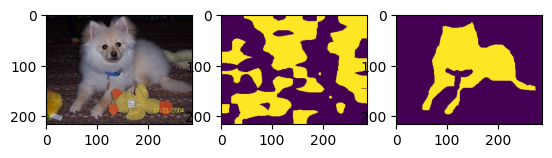

In [10]:
import matplotlib.pyplot as plt

NUM_VIS_IMG = 0
f, axes = plt.subplots(1,3)
axes[0].imshow(np.array(Image.open(os.path.join(val_imgs_path, val_img_names[NUM_VIS_IMG]))))
axes[1].imshow(val_seg_masks[NUM_VIS_IMG])
axes[2].imshow(np.array(Image.open(os.path.join(val_masks_path, val_img_names[NUM_VIS_IMG].replace('jpg', 'png')))))

Well...🥴

But anyway, let's now calculate val metric, and then generate segmentation maps for test set and form test submission.

In the cell below there's a code of IoU metric for binary segmentation. This is how your score will be calculated in Kaggle:

In [37]:
def binaryMaskIOU(mask1, mask2):
    assert mask1.shape == mask2.shape
    mask1_area = np.count_nonzero(mask1 == 1)
    mask2_area = np.count_nonzero(mask2 == 1)
    intersection = np.count_nonzero(np.logical_and(mask1==1,  mask2==1))
    iou = intersection/(mask1_area+mask2_area-intersection)
    return iou

Let's calculate metric for val data:

In [38]:
val_ious = []
for img_name, seg_mask in zip(val_img_names, val_seg_masks):

    mask = Image.open(os.path.join(val_masks_path, img_name.replace('.jpg', '.png')))
    mask = np.array(mask)//255
    iou = binaryMaskIOU(seg_mask, mask)
    val_ious.append(iou)

In [39]:
np.mean(val_ious)

0.3552482754461087

Okay, now let's build the solution for test set. Note that this takes ~30 minutes to run in Kaggle. Which means, you better create a **smarter** solution. Who knows if this can make Laida angry...

In [ ]:
test_imgs_path = '/kaggle/input/neoai-2025-cuties-segmentation/cuties/test_imgs'
test_img_names, test_seg_masks = generate_seg_masks(test_imgs_path, classes_encoded)

In [ ]:
from io import BytesIO
import base64
import pandas as pd

def image_to_base64(image: Image.Image, fmt: str = "PNG") -> str:
    """ Конвертирует картинку PIL.Image в base64 (текстовый формат). """
    buf = BytesIO()
    image.save(buf, format=fmt)
    return base64.b64encode(buf.getvalue()).decode("utf-8")

ids = []
b64 = []

for img_name, seg_mask in zip(test_img_names, test_seg_masks):
    ids.append(img_name[:-4]) # get rid og .jpg part
    mask = Image.fromarray(255*seg_mask)
    b64.append(image_to_base64(mask.convert("L")))

pred_pd = pd.DataFrame({"img_id": [int(id_) for id_ in ids], "mask": b64})
pred_pd.to_csv('test_submission.csv', index=False)

This file can be submitted into the competition. Good luck!